In [5]:
""" Figure out what is limiting the uptake rate of each pathway and NPP """
import xarray as xr
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap
import warnings

warnings.filterwarnings('ignore')

LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                    0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                    7.829766, 12.92532, 21.32647, 35.17762])
LEVGRND_I = np.append(np.insert(
    (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
THICKNESS = np.diff(LEVGRND_I)

chambers_ordered = {
    'amb': ['06', '20', '13', '08', '17'],
    'elev': ['19', '11', '04', '16', '10']
}

tair = ['+0', '+2.25', '+4.5', '+6.75', '+9']

In [9]:
prefix = '20240406'
pft = 11
hol_add = 17
tvec = pd.date_range('2015-01-01', '2024-01-01', freq = '1D')
tvec = tvec[(tvec.month !=2) | (tvec.day != 29)]

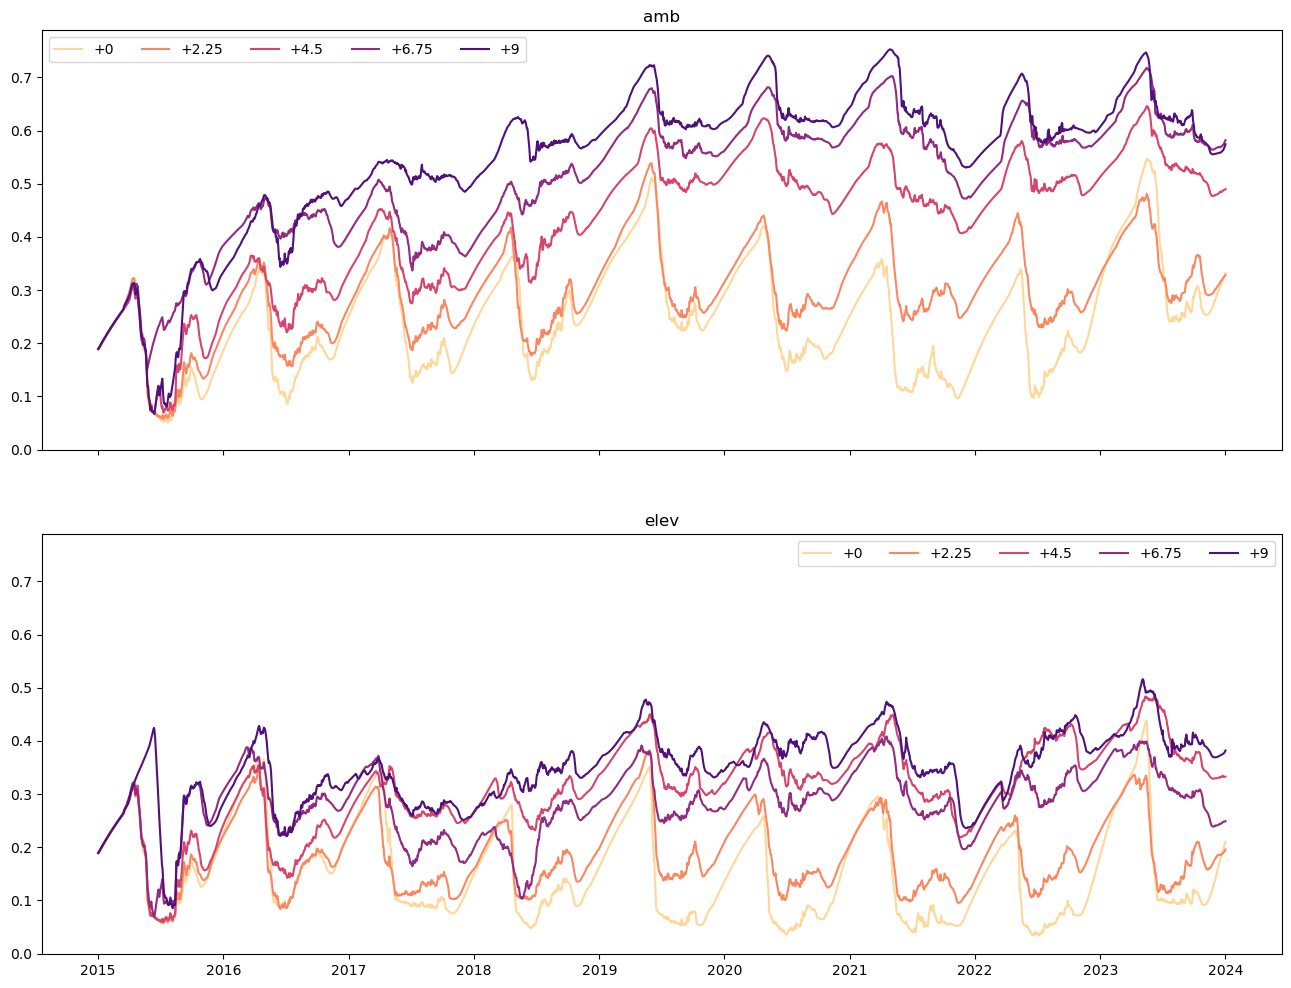

In [10]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 1, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):
    ax = axes.flat[j]

    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        filt = (hr['time'].to_index().month >= 1) & (hr['time'].to_index().month <= 12)

        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )

        data_hummock = (hr['ROOTFR'][:,:10,pft] * \
                        hr['FFR_N_PATCH'][:,:10,pft].values).sum(axis=1)
        data_hollow = (hr['ROOTFR'][:,:10,pft] * \
                       hr['FFR_N_PATCH'][:,:10,pft+hol_add].values).sum(axis=1)

        #data_hummock = (hr['FUNGI_INHIB_PATCH'][:,pft]*hr['FROOTC'][:,pft]* \
        #    hr['ROOTFR'][:,:10,pft] * \
        #    hr['FFR_TSOI_PATCH'][:,:10,pft].values * \
        #    hr['FFR_SWC_PATCH'][:,:10,pft].values * \
        #    hr['FFR_FPG_PATCH'][:,pft]*hr['FFN_NSC_PATCH'][:,pft]).sum(axis = 1)
        #data_hollow = (hr['FUNGI_INHIB_PATCH'][:,pft+hol_add]*hr['FROOTC'][:,pft+hol_add]* \
        #    hr['ROOTFR'][:,:10,pft+hol_add] * \
        #    hr['FFR_TSOI_PATCH'][:,:10,pft+hol_add].values * \
        #    hr['FFR_SWC_PATCH'][:,:10,pft+hol_add].values * \
        #    hr['FFR_FPG_PATCH'][:,pft+hol_add]* \
        #    hr['FFN_NSC_PATCH'][:,pft+hol_add]).sum(axis = 1)

        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color, label = tair[i])
        hr.close()

    ax.legend(ncol = 5)
    ax.set_title(co2)

/tmp/ipykernel_3893974/1392205230.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


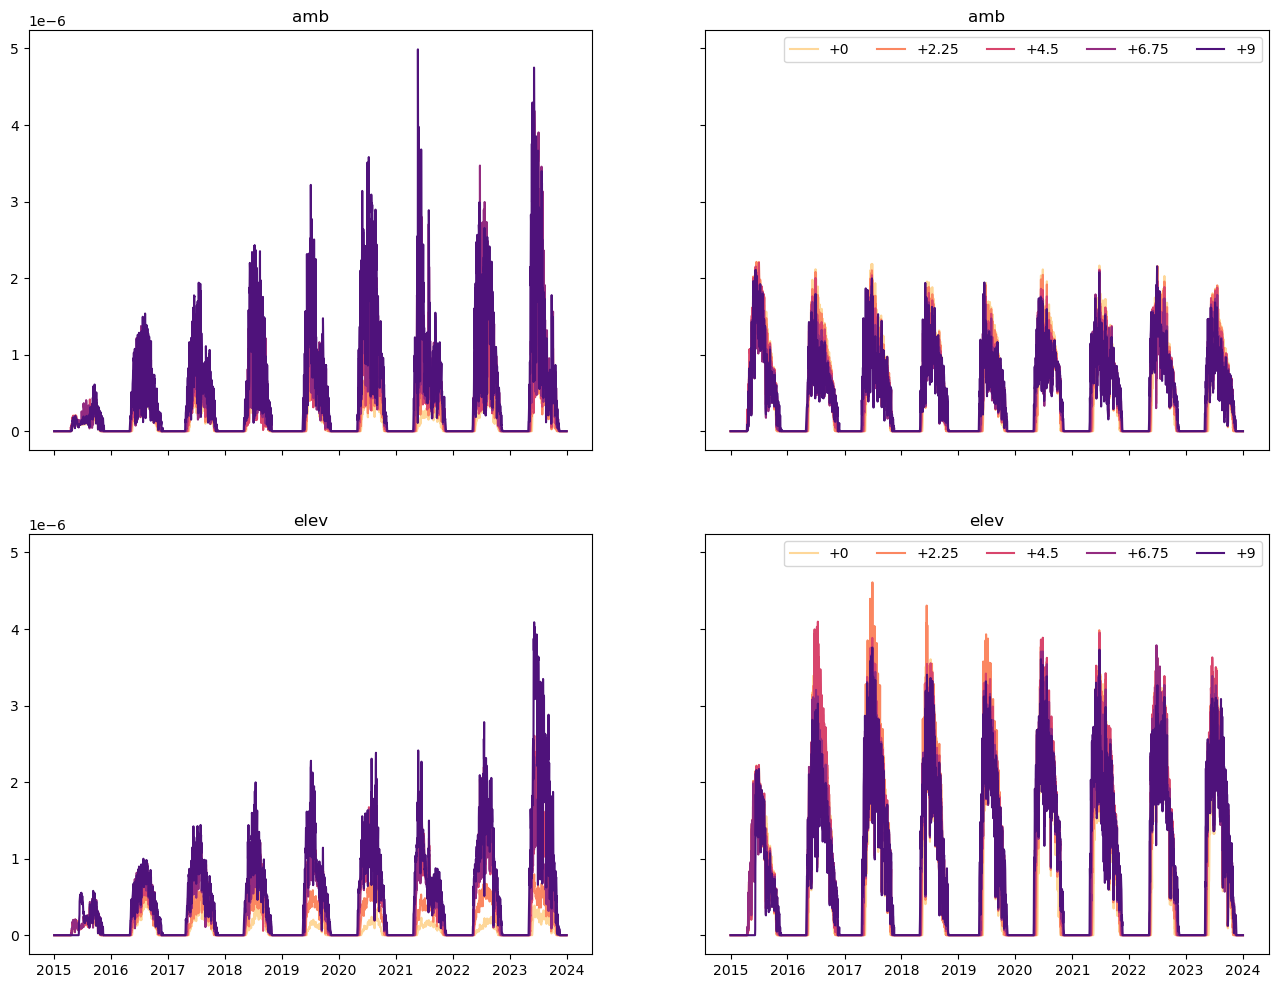

In [89]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):
    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        filt = (hr['time'].to_index().month >= 1) & (hr['time'].to_index().month <= 12)

        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )

        ax = axes[j, 0]
        data_hummock = hr['SMINN_TO_NPOOL'][:,pft].values
        data_hollow = hr['SMINN_TO_NPOOL'][:,pft + hol_add].values
        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')

        ax = axes[j, 1]
        data_hummock = hr['PLANT_NDEMAND'][:,pft].values
        data_hollow = hr['PLANT_NDEMAND'][:,pft + hol_add].values
        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')

        hr.close()

    ax.legend(ncol = 5)

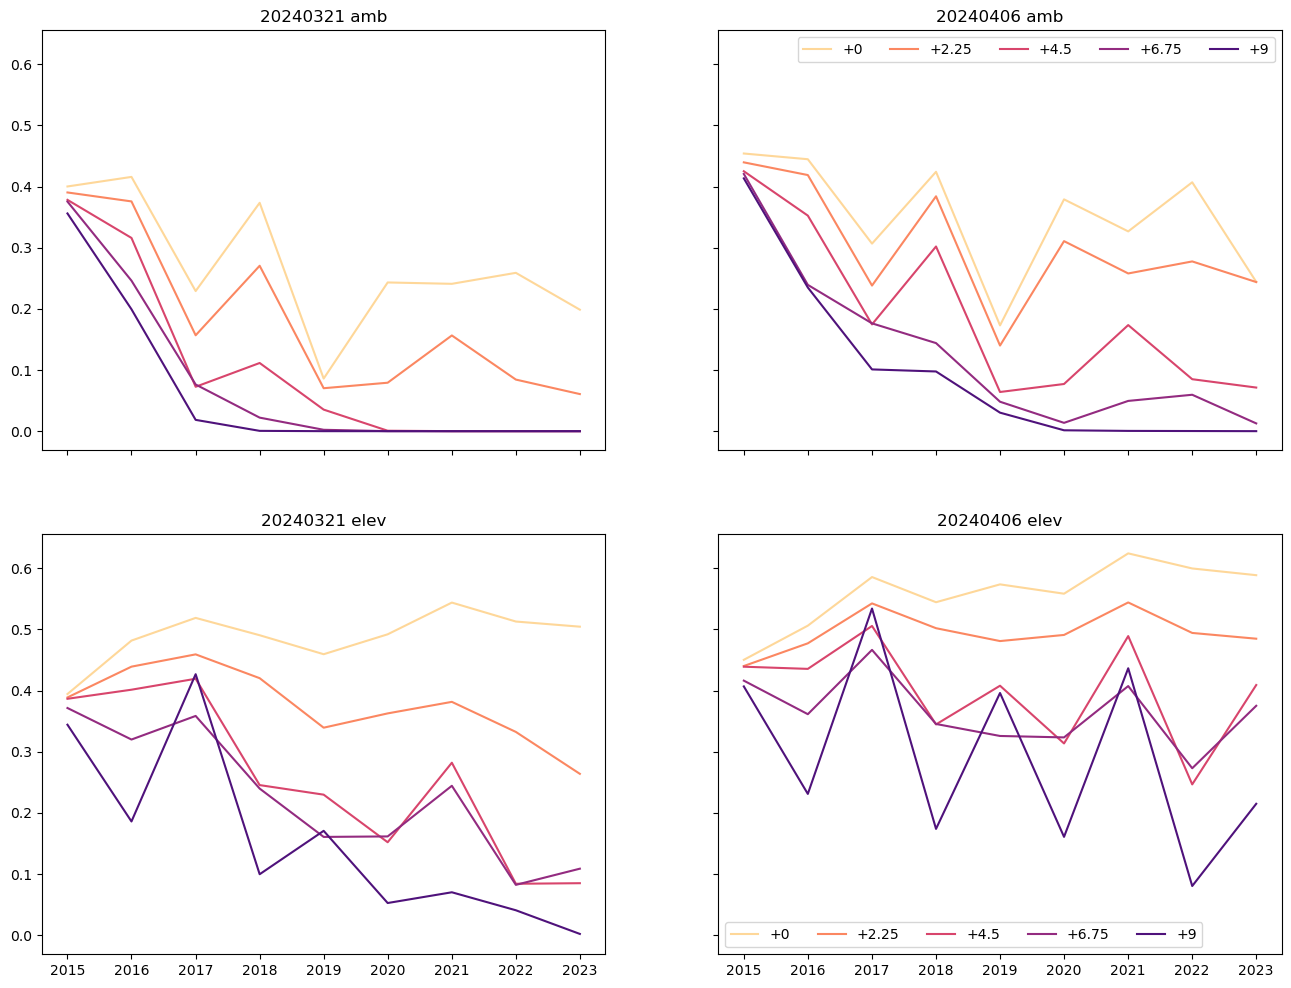

In [3]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):

    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        ax = axes[j,0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['XR'][:,pft].resample(time='1Y').mean().values / \
            hr['GPP'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['XR'][:,pft].resample(time='1Y').mean().values / \
            hr['GPP'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

        ax = axes[j,1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['XR'][:,pft].resample(time='1Y').mean().values / \
            hr['GPP'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['XR'][:,pft].resample(time='1Y').mean().values / \
            hr['GPP'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

    ax.legend(ncol = 5)

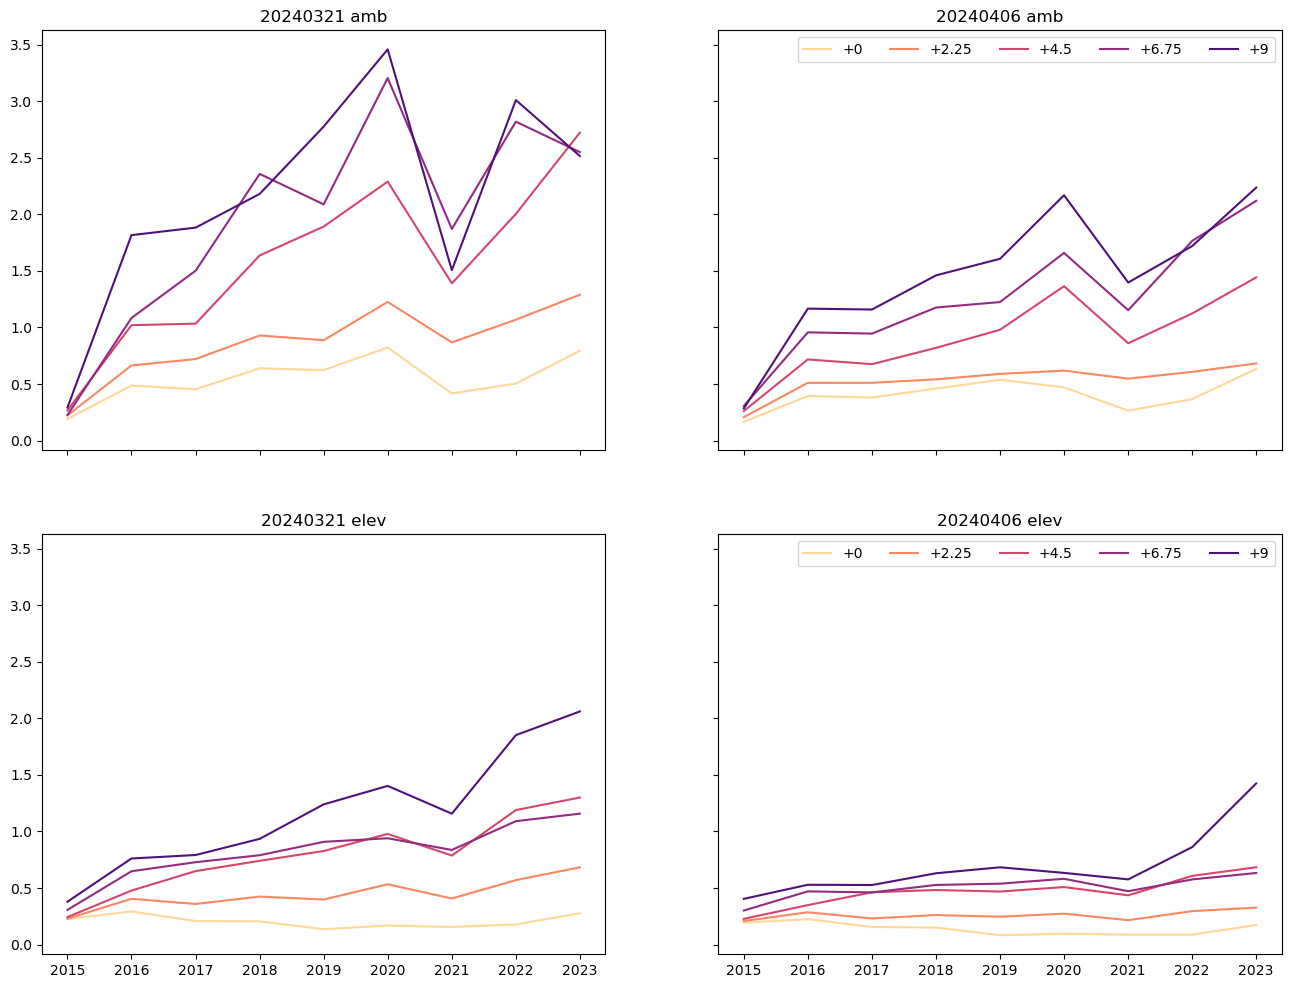

In [4]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):

    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        ax = axes[j,0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['SMINN_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['SMINN_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

        ax = axes[j,1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['SMINN_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['SMINN_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

    ax.legend(ncol = 5)

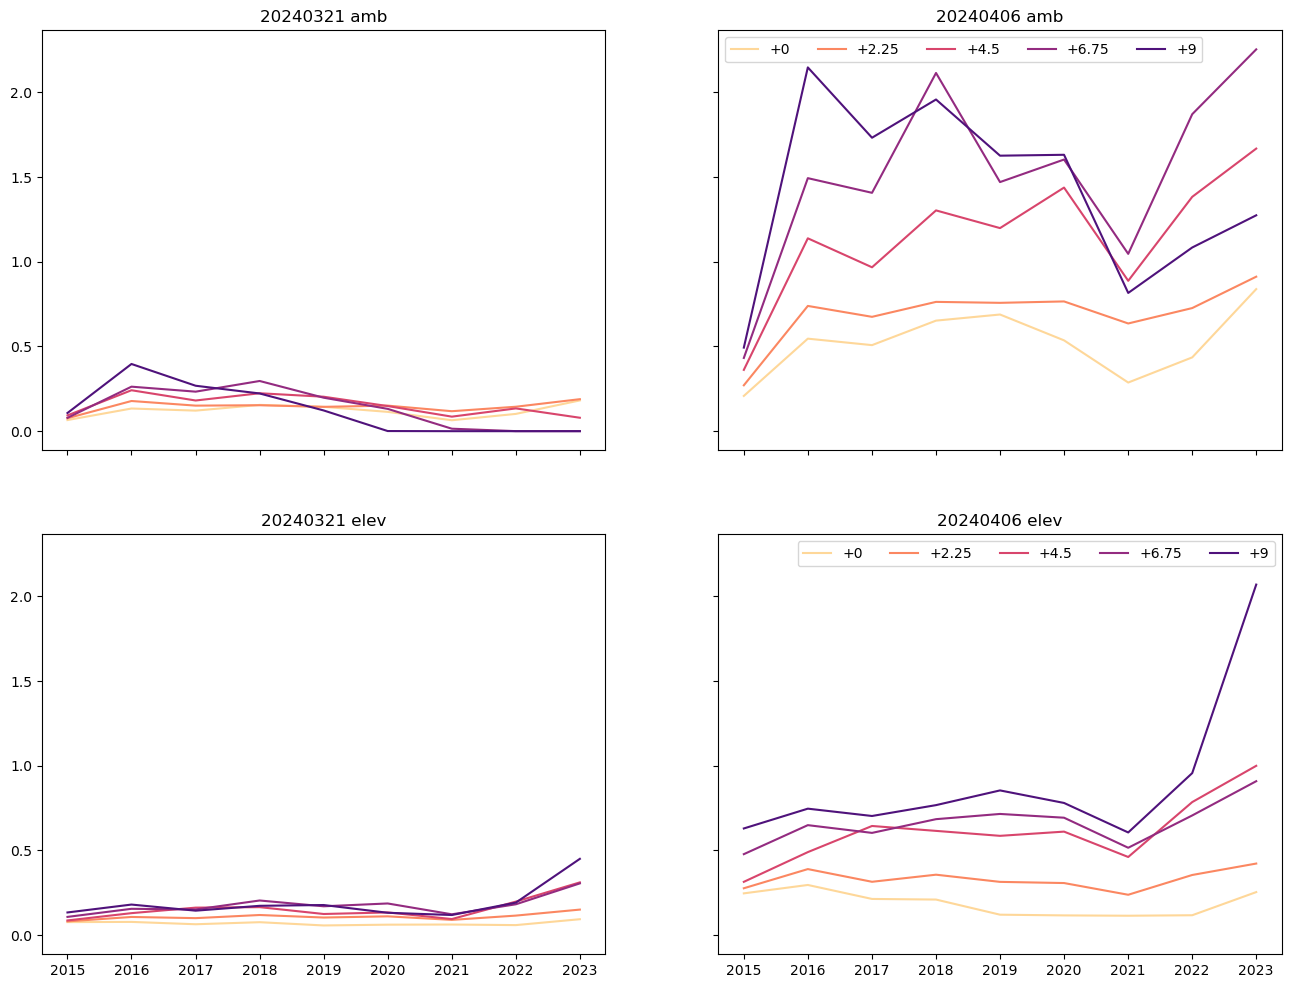

In [105]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):

    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        ax = axes[j,0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FUNGI_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['FUNGI_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

        ax = axes[j,1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FUNGI_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['FUNGI_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

    ax.legend(ncol = 5)

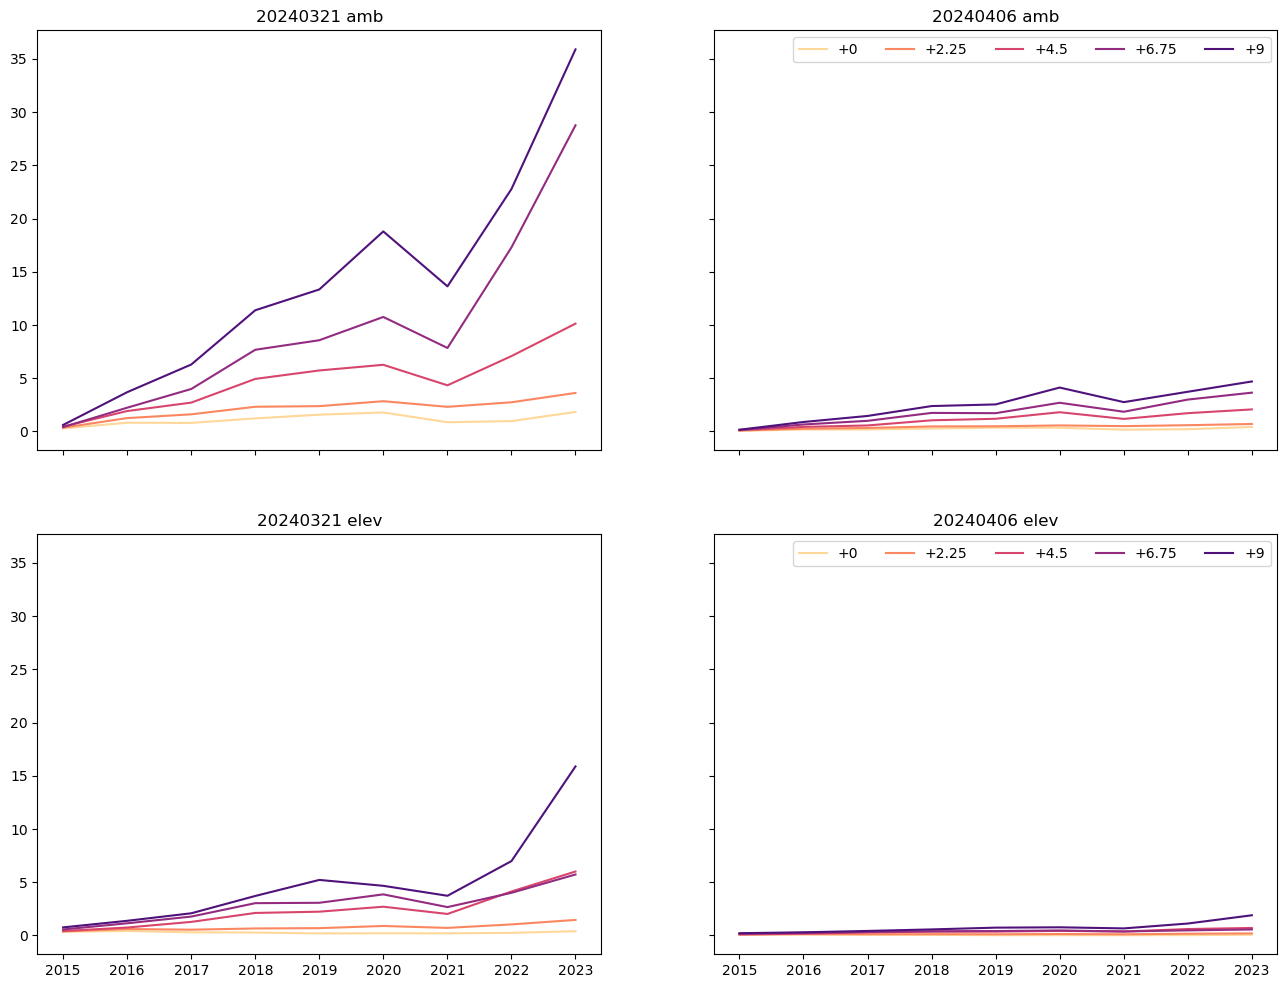

In [106]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):

    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        ax = axes[j,0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FROOT_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['FROOT_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

        ax = axes[j,1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FROOT_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['FROOT_NDEMAND_POT'][:,pft].resample(time='1Y').mean().values / \
            hr['PLANT_NDEMAND'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

    ax.legend(ncol = 5)

/tmp/ipykernel_3893974/3834610679.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


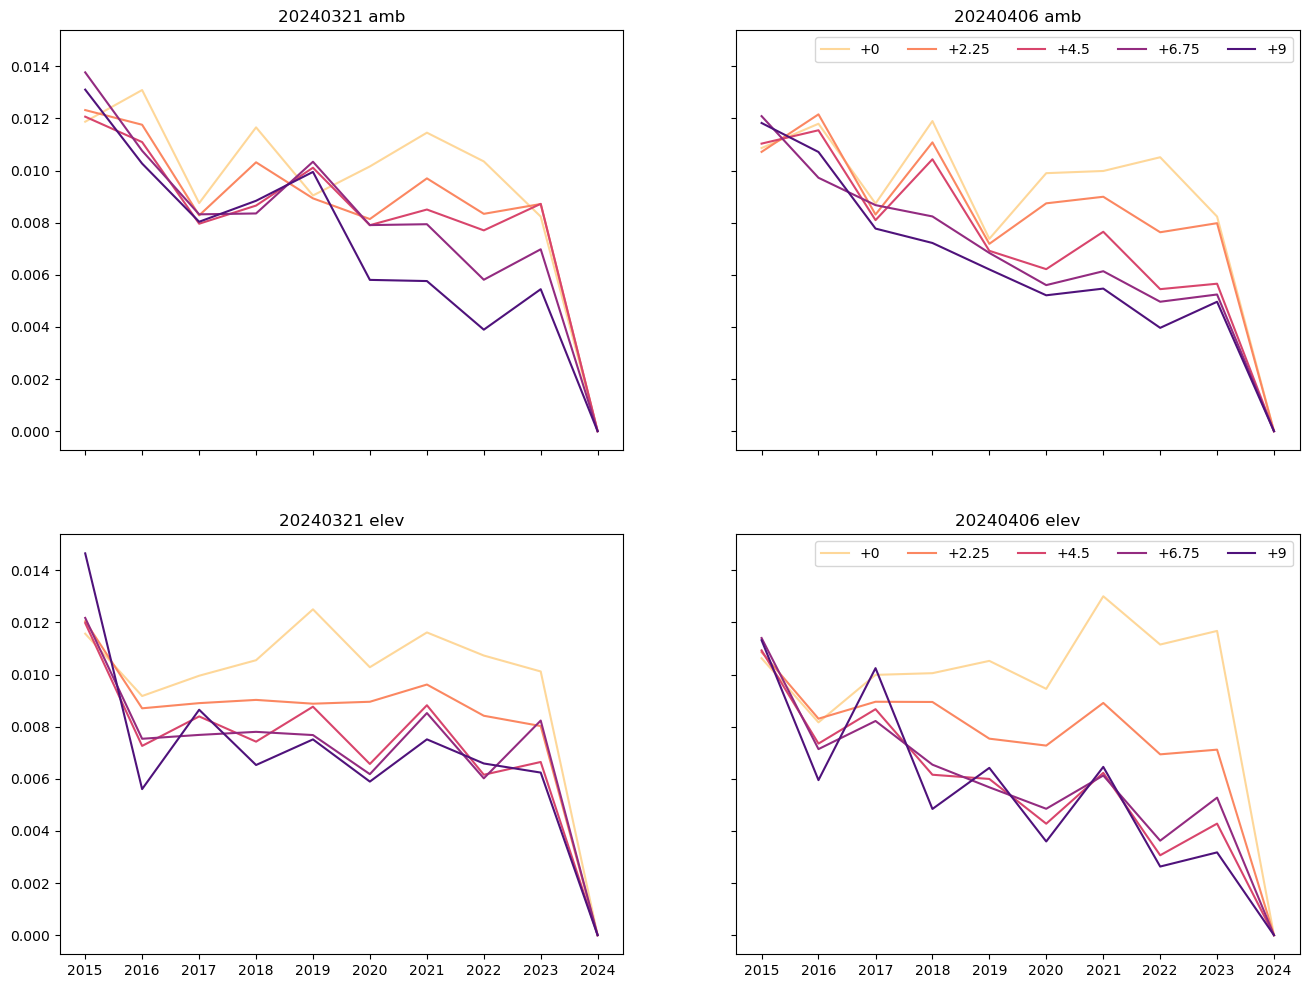

In [102]:
cmap = get_cmap('magma_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):

    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)

        ax = axes[j,0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FUNGI_SOM_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['NPP'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['FUNGI_SOM_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['NPP'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

        ax = axes[j,1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FUNGI_SOM_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['NPP'][:,pft].resample(time='1Y').mean().values
        data_hollow = hr['FUNGI_SOM_TO_NPOOL'][:,pft].resample(time='1Y').mean().values / \
            hr['NPP'][:,pft].resample(time='1Y').mean().values
        ax.plot(tvec[tvec.dayofyear == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])
        ax.set_title(f'{prefix} {co2}')
        hr.close()

    ax.legend(ncol = 5)

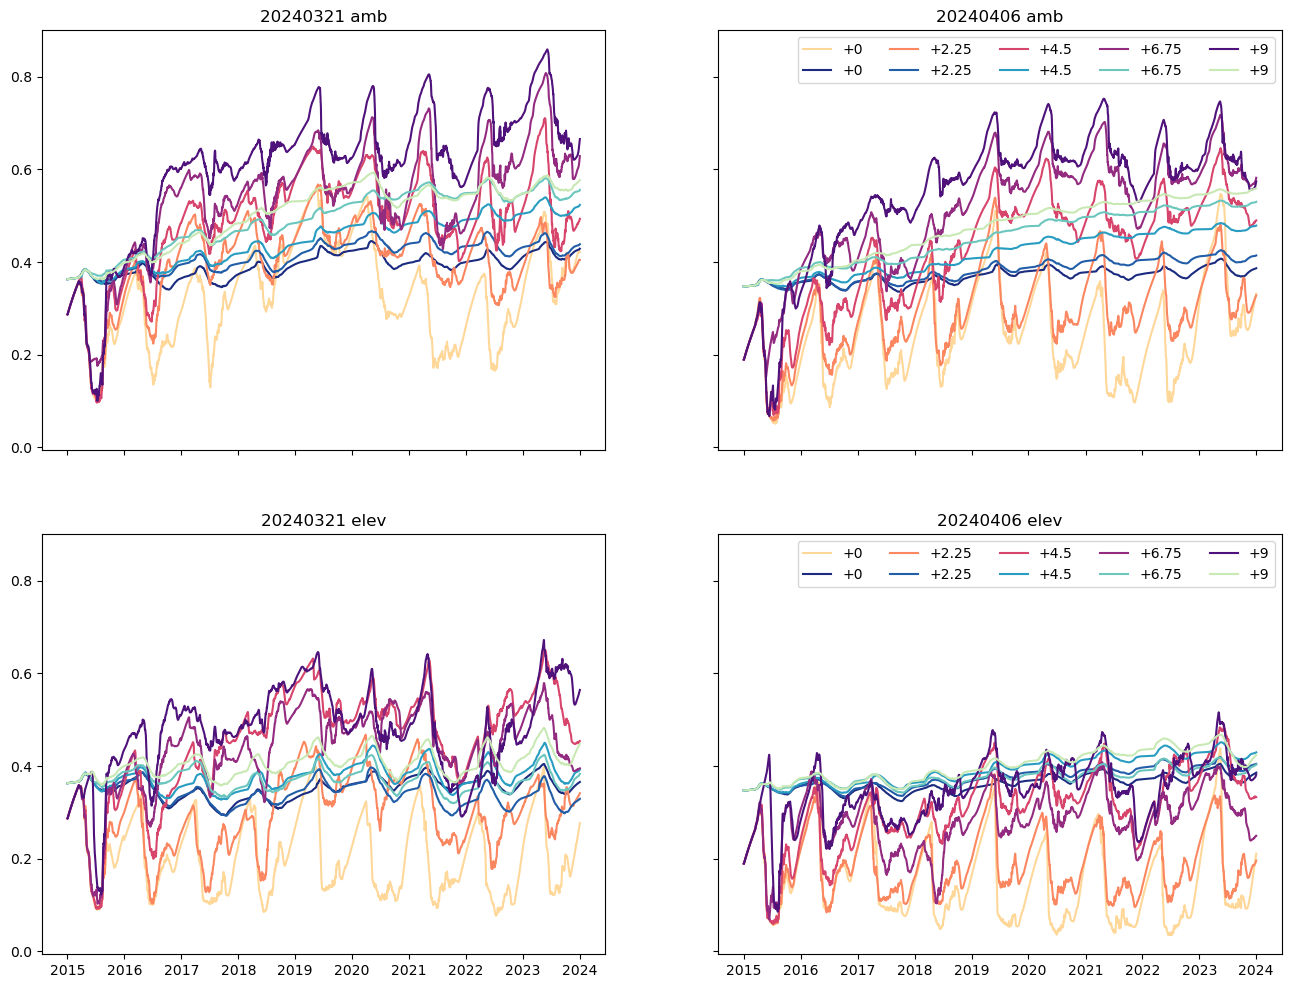

In [18]:
cmap = get_cmap('magma_r')
cmap_p = get_cmap('YlGnBu_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):
    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)
        color_p = cmap_p((i+0.5)/6)

        filt = (hr['time'].to_index().month >= 1) & (hr['time'].to_index().month <= 12)

        ax = axes[j, 0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = (hr['ROOTFR'][:,:10,pft] * \
                        hr['FFR_N_PATCH'][:,:10,pft].values).sum(axis=1)
        data_hollow = (hr['ROOTFR'][:,:10,pft] * \
                       hr['FFR_N_PATCH'][:,:10,pft+hol_add].values).sum(axis=1)
        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color, label = tair[i])

        data_hummock = (hr['ROOTFR'][:,:10,pft] * \
                        hr['FFR_P_PATCH'][:,:10,pft].values).sum(axis=1)
        data_hollow = (hr['ROOTFR'][:,:10,pft] * \
                       hr['FFR_P_PATCH'][:,:10,pft+hol_add].values).sum(axis=1)
        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color_p, label = tair[i])
        hr.close()
        ax.set_title(f'{prefix} {co2}')

        ax = axes[j, 1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = (hr['ROOTFR'][:,:10,pft] * \
                        hr['FFR_N_PATCH'][:,:10,pft].values).sum(axis=1)
        data_hollow = (hr['ROOTFR'][:,:10,pft] * \
                       hr['FFR_N_PATCH'][:,:10,pft+hol_add].values).sum(axis=1)
        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color, label = tair[i])

        data_hummock = (hr['ROOTFR'][:,:10,pft] * \
                        hr['FFR_P_PATCH'][:,:10,pft].values).sum(axis=1)
        data_hollow = (hr['ROOTFR'][:,:10,pft] * \
                       hr['FFR_P_PATCH'][:,:10,pft+hol_add].values).sum(axis=1)
        ax.plot(tvec[filt], data_hummock[filt]*0.64 + data_hollow[filt]*0.36,
                color = color_p, label = tair[i])

        hr.close()
        ax.set_title(f'{prefix} {co2}')

    ax.legend(ncol = 5)

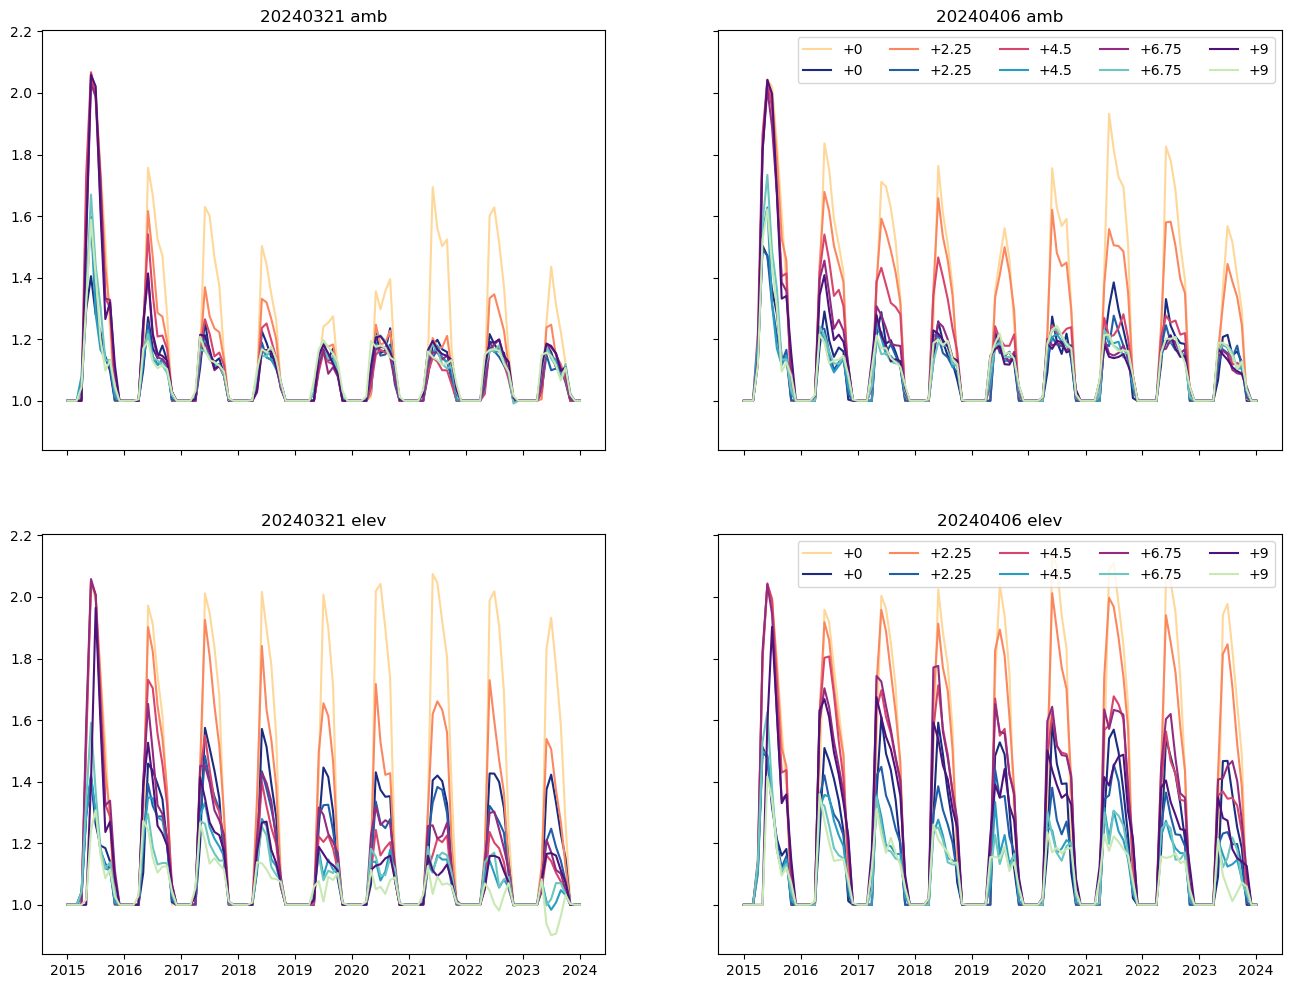

In [32]:
cmap = get_cmap('magma_r')
cmap_p = get_cmap('YlGnBu_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):
    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)
        color_p = cmap_p((i+0.5)/6)

        ax = axes[j, 0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FFR_FPG_PATCH'][:,pft].resample(time='1M').mean().values
        data_hollow =hr['FFR_FPG_PATCH'][:,pft+hol_add].resample(time='1M').mean().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])

        data_hummock = hr['FFR_FPG_P_PATCH'][:,pft].resample(time='1M').mean().values
        data_hollow =hr['FFR_FPG_P_PATCH'][:,pft+hol_add].resample(time='1M').mean().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color_p, label = tair[i])
        hr.close()
        ax.set_title(f'{prefix} {co2}')

        ax = axes[j, 1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FFR_FPG_PATCH'][:,pft].resample(time='1M').mean().values
        data_hollow =hr['FFR_FPG_PATCH'][:,pft+hol_add].resample(time='1M').mean().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])

        data_hummock = hr['FFR_FPG_P_PATCH'][:,pft].resample(time='1M').mean().values
        data_hollow =hr['FFR_FPG_P_PATCH'][:,pft+hol_add].resample(time='1M').mean().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color_p, label = tair[i])

        hr.close()
        ax.set_title(f'{prefix} {co2}')

    ax.legend(ncol = 5)

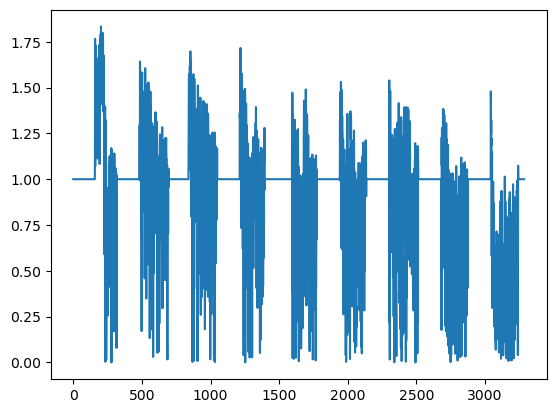

In [38]:
plt.plot(1.5 / (np.power(hr['FPG_PATCH'][:,pft].values, 2) + 1.5 - 1))

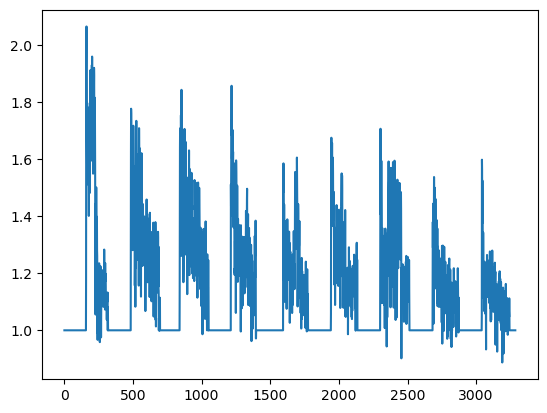

In [39]:
plt.plot(hr['FFR_FPG_PATCH'][:,pft].values)

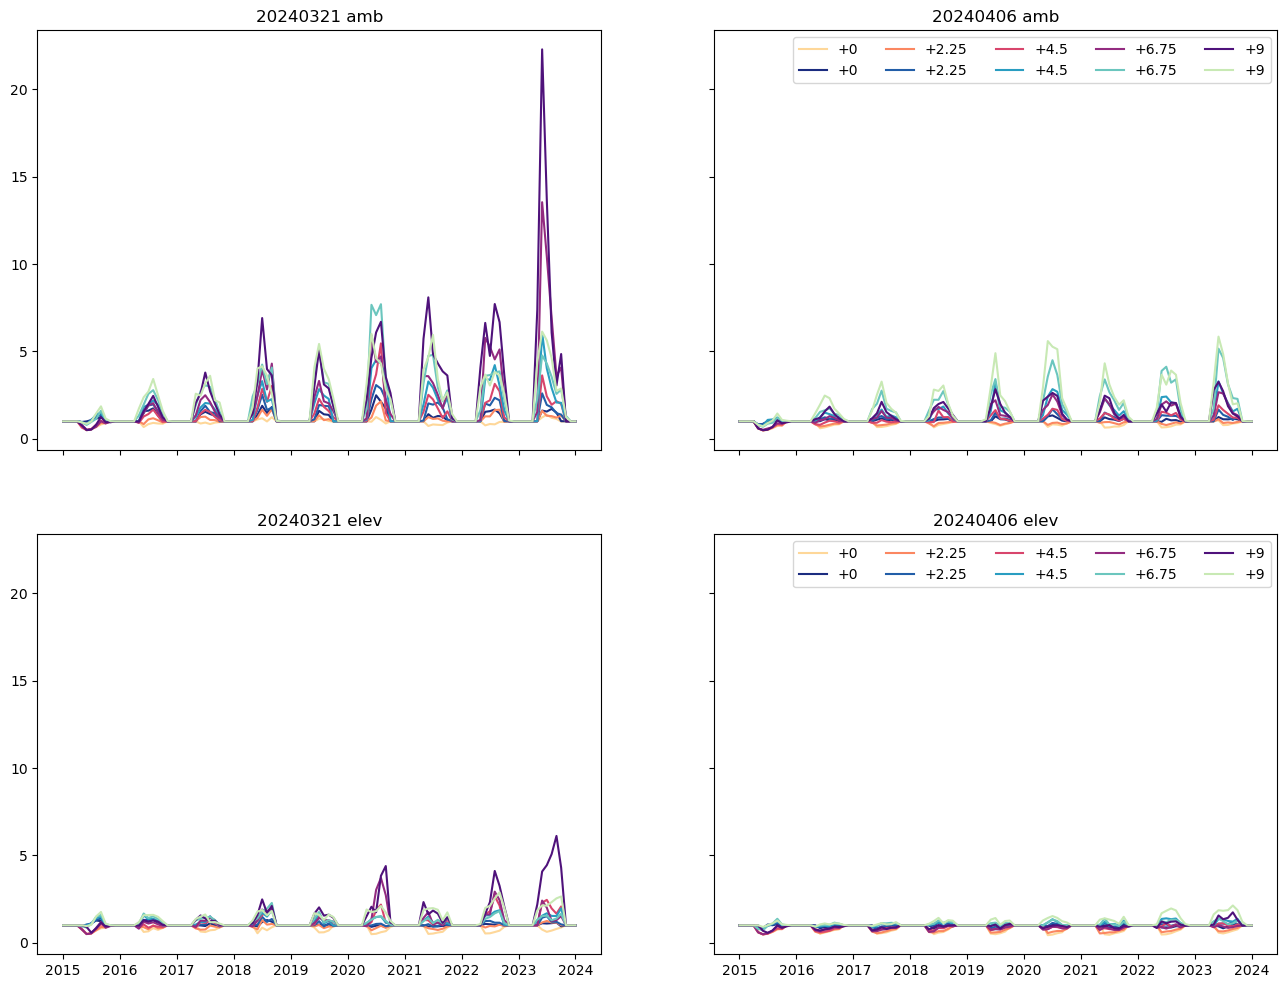

In [31]:
cmap = get_cmap('magma_r')
cmap_p = get_cmap('YlGnBu_r')
fig, axes = plt.subplots(2, 2, figsize = (16, 12), sharex = True, sharey = True)

for j, co2 in enumerate(['amb', 'elev']):
    for i, plot in enumerate(chambers_ordered[co2]):
        color = cmap((i+0.5)/6)
        color_p = cmap_p((i+0.5)/6)

        ax = axes[j, 0]
        prefix = '20240321'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FPG_PATCH'][:,pft].load().resample(time='1M').median().values
        data_hollow =hr['FPG_PATCH'][:,pft+hol_add].load().resample(time='1M').median().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])

        data_hummock = hr['FPG_P_PATCH'][:,pft].load().resample(time='1M').median().values
        data_hollow =hr['FPG_P_PATCH'][:,pft+hol_add].load().resample(time='1M').median().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color_p, label = tair[i])
        hr.close()
        ax.set_title(f'{prefix} {co2}')

        ax = axes[j, 1]
        prefix = '20240406'
        hr = xr.open_mfdataset(
            os.path.join(os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC',
                        'spruce_treatments', f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
                        '*.h2.*.nc')
        )
        data_hummock = hr['FPG_PATCH'][:,pft].load().resample(time='1M').median().values
        data_hollow =hr['FPG_PATCH'][:,pft+hol_add].load().resample(time='1M').median().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color, label = tair[i])

        data_hummock = hr['FPG_P_PATCH'][:,pft].load().resample(time='1M').median().values
        data_hollow =hr['FPG_P_PATCH'][:,pft+hol_add].load().resample(time='1M').median().values
        ax.plot(tvec[tvec.day == 1], data_hummock*0.64 + data_hollow*0.36,
                color = color_p, label = tair[i])

        hr.close()
        ax.set_title(f'{prefix} {co2}')

    ax.legend(ncol = 5)